### **1. Kütüphanelerin Yüklenmesi**
PCA işlemine başlamadan önce veri manipülasyonu, görselleştirme ve modelleme için gerekli olan temel Python kütüphanelerini içe aktarıyoruz.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

---
### **2. Veri Setinin Yüklenmesi ve İncelenmesi**
Scikit-learn kütüphanesinin içinde hazır bulunan Meme Kanseri (Breast Cancer) veri setini kullanacağız. Bu veri seti, tümörlerin iyi huylu mu yoksa kötü huylu mu olduğunu belirten 30 farklı özellik (boyut) içerir.

In [3]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df['target'] = cancer['target']

print('Veri Seti Boyutu:', df.shape)
display(df.head())

Veri Seti Boyutu: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
### **3. Veri Standardizasyonu (Ölçeklendirme)**
PCA algoritması, verilerin ölçeğine (varyansına) karşı oldukça hassastır. Uygulamadan önce verilerimizi ortalaması 0, standart sapması 1 olacak şekilde standartlaştırmalıyız.

In [4]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Ölçeklendirilmiş verinin ilk satırı:\n', X_scaled[0])

Ölçeklendirilmiş verinin ilk satırı:
 [ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633  3.28351467
  2.65287398  2.53247522  2.21751501  2.25574689  2.48973393 -0.56526506
  2.83303087  2.48757756 -0.21400165  1.31686157  0.72402616  0.66081994
  1.14875667  0.90708308  1.88668963 -1.35929347  2.30360062  2.00123749
  1.30768627  2.61666502  2.10952635  2.29607613  2.75062224  1.93701461]


---
### **4. Temel Bileşenler Analizi (PCA) Uygulaması**
Şimdi 30 boyutlu (30 sütunlu) veri setimizi, görselleştirebilmek amacıyla 2 boyuta (2 temel bileşene) düşüreceğiz.

In [5]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data = principal_components, 
                      columns = ['Birinci Temel Bilesen', 'Ikinci Temel Bilesen'])

pca_df['Hedef'] = y
display(pca_df.head())

,Birinci Temel Bilesen,Ikinci Temel Bilesen,Hedef
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0
3,7.122953,10.275589,0
4,3.935302,-1.948072,0


---
### **5. PCA Sonucunun Görselleştirilmesi**
İnsan beyni 30 boyutlu veriyi algılayamaz ancak 2 boyutlu bir düzlemde saçılım grafiği (scatter plot) ile verinin nasıl kümelendiğini çok rahat görebiliriz.

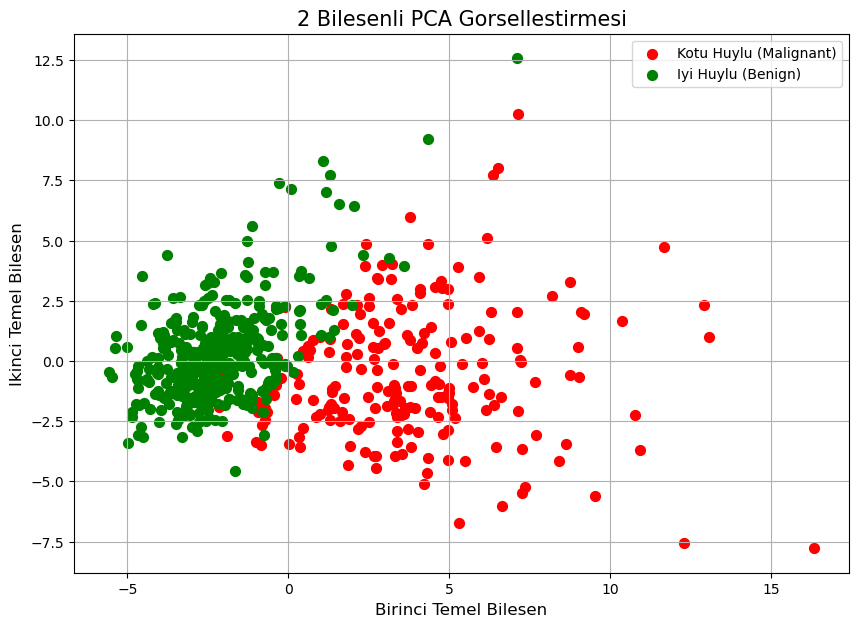

In [6]:
plt.figure(figsize=(10, 7))

targets = [0, 1]
colors = ['r', 'g']
labels = ['Kotu Huylu (Malignant)', 'Iyi Huylu (Benign)']

for target, color, label in zip(targets, colors, labels):
    indicesToKeep = pca_df['Hedef'] == target
    plt.scatter(pca_df.loc[indicesToKeep, 'Birinci Temel Bilesen'],
                pca_df.loc[indicesToKeep, 'Ikinci Temel Bilesen'],
                c = color, 
                s = 50,
                label = label)

plt.xlabel('Birinci Temel Bilesen', fontsize=12)
plt.ylabel('Ikinci Temel Bilesen', fontsize=12)
plt.title('2 Bilesenli PCA Gorsellestirmesi', fontsize=15)
plt.legend()
plt.grid(True)
plt.show()

---
### **6. Açıklanan Varyans Oranı (Explained Variance Ratio)**
Boyutları 30'dan 2'ye düşürdük, peki ama orijinal verideki bilginin (varyansın) ne kadarını kaybettik? Bunu `explained_variance_ratio_` metodu ile görebiliriz.

In [7]:
varyans_oranlari = pca.explained_variance_ratio_

print(f'Birinci Temel Bilesen bilginin %{varyans_oranlari[0]*100:.2f}sini acikliyor.')
print(f'Ikinci Temel Bilesen bilginin %{varyans_oranlari[1]*100:.2f}sini acikliyor.')
print(f'Toplam korunan bilgi (varyans): %{(varyans_oranlari[0] + varyans_oranlari[1])*100:.2f}')

Birinci Temel Bilesen bilginin %44.27sini acikliyor.
Ikinci Temel Bilesen bilginin %18.97sini acikliyor.
Toplam korunan bilgi (varyans): %63.24
